# ✈️ Flight Delay & Cancellation Analysis (2019–2023)

An end-to-end analysis of ~3 million US domestic flights to understand delay patterns, cancellation causes, and airline performance across five years.

**Dataset:** [Kaggle – Flight Delay and Cancellation Dataset 2019–2023](https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023)  
**Source:** US Bureau of Transportation Statistics (BTS)  
**Coverage:** 3,000,000 flights · 18 airlines · 380 airports · Jan 2019 – Aug 2023

---

## Questions answered

| # | Question |
|---|---|
| Q1 | What is the average arrival delay per airline? |
| Q2 | Which airlines have the highest delay frequency? |
| Q3 | What is the most common cause of delays? |
| Q4 | Does delay vary by day of the week? |
| Q5 | Does delay vary by month? |
| Q6 | Does a departure delay predict an arrival delay? |


---

## Key findings (summary)

- **Worst airline:** Allegiant Air — 13.4 min avg arrival delay; 26% of flights delayed
- **Best airline:** Endeavor Air (9E) — the only airline arriving early on average
- **Main delay cause:** Late Aircraft (37.7%) + Carrier (36.7%) = 74% of all delay minutes
- **Worst month:** June (11.0 min avg) driven by summer demand and thunderstorm season
- **Best month:** September (0.8 min avg) — post-summer lull, schools back, no holidays
- **Worst day:** Friday (6.7 min) · **Best day:** Tuesday (2.7 min)
- **Departure delay predicts arrival delay** with r = 0.965; airlines recover ~6 min on average

---
## 0 · Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import zipfile
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

# ── Constants (defined here so every cell can reference them) ─────────────────
CAUSE_COLS = [
    "DELAY_DUE_CARRIER",
    "DELAY_DUE_WEATHER",
    "DELAY_DUE_NAS",
    "DELAY_DUE_SECURITY",
    "DELAY_DUE_LATE_AIRCRAFT",
]

MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

DOW_ORDER = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

FULL_NORMAL_YEARS = [2019, 2021, 2022]
# 2020 excluded: COVID caused ~37% fewer flights, distorts averages
# 2023 excluded: partial year (January–August only)

print("Libraries loaded ✓")

Libraries loaded ✓


---
## 1 · Data Loading

The dataset is a single CSV inside the Kaggle zip. I extract it and load it.

Column names are already in the desired format (`FL_DATE`, `AIRLINE_CODE`, etc.), so no renaming is required.

In [2]:
# Download from Kaggle (uncomment if running for the first time)
# !kaggle datasets download -d patrickzel/flight-delay-and-cancellation-dataset-2019-2023

# Unzip into data/raw/
with zipfile.ZipFile(
    "flight-delay-and-cancellation-dataset-2019-2023.zip", "r"
) as zip_ref:
    zip_ref.extractall("data/raw")

# Find and load the CSV
csv_files = glob.glob("data/raw/**/*.csv", recursive=True)
print("Files found:", csv_files)

df_raw = pd.read_csv(csv_files[0], low_memory=False)
print(f"Rows: {len(df_raw):,}   Columns: {df_raw.shape[1]}")
df_raw.head(3)

Files found: ['data/raw\\flights_sample_3m.csv']
Rows: 3,000,000   Columns: 32


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.00,-4.00,19.00,1210.00,1443.00,4.00,1501,1447.00,-14.00,0.00,NaN,0.00,186.00,176.00,153.00,1065.00,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.00,-6.00,9.00,2123.00,2232.00,38.00,2315,2310.00,-5.00,0.00,NaN,0.00,235.00,236.00,189.00,1399.00,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.00,6.00,20.00,1020.00,1247.00,5.00,1252,1252.00,0.00,0.00,NaN,0.00,118.00,112.00,87.00,680.00,NaN,NaN,NaN,NaN,NaN


---
## 2 · Data Cleaning

I work through cleaning in logical steps, verifying each assumption against the data before acting on it.

### 2.1 · Missing value overview

In [3]:
missing = (
    df_raw.isnull().sum()
    .to_frame("null_count")
    .assign(null_pct=lambda x: (x["null_count"] / len(df_raw) * 100).round(2))
    .query("null_count > 0")
    .sort_values("null_pct", ascending=False)
)
print("Columns with missing values:")
display(missing)

Columns with missing values:


,null_count,null_pct
CANCELLATION_CODE,2920860,97.36
DELAY_DUE_CARRIER,2466137,82.20
DELAY_DUE_SECURITY,2466137,82.20
DELAY_DUE_NAS,2466137,82.20
DELAY_DUE_WEATHER,2466137,82.20
DELAY_DUE_LATE_AIRCRAFT,2466137,82.20
ARR_DELAY,86198,2.87
ELAPSED_TIME,86198,2.87
AIR_TIME,86198,2.87
ARR_TIME,79942,2.66


**Missing value interpretation:**

| Group | Columns | % Missing | Explanation |
|---|---|---|---|
| Cancellation code | `CANCELLATION_CODE` | 97.36% | Only 2.64% of flights are cancelled — confirmed below |
| Delay causes | `DELAY_DUE_*` | 82.20% | BTS only requires cause reporting for ARR_DELAY ≥ 15 min — NaN means 0 minutes |
| Arrival metrics | `ARR_DELAY`, `ARR_TIME`, etc. | ~2.87% | Cancelled/diverted flights have no actual arrival — expected |
| Departure metrics | `DEP_DELAY`, `DEP_TIME`, etc. | ~2.59% | Slightly fewer than arrival — a flight can depart but divert |
| `CRS_ELAPSED_TIME` | Scheduled elapsed time | ~0% (14 rows) | Investigated below — all 14 are cancelled flights |

### 2.2 · Verify missing value assumptions

Before cleaning, I verify each assumption directly rather than inferring from percentages.

In [4]:
# ── Group 1: Cancellation codes ───────────────────────────────────────────────
# Hypothesis: CANCELLATION_CODE is missing exactly because the flight was not cancelled.
# If true, the cancellation rate should equal the non-null code rate.

cancel_rate = df_raw["CANCELLED"].mean() * 100
non_null_codes = df_raw["CANCELLATION_CODE"].notna().sum()
print(f"Cancelled flights      : {df_raw['CANCELLED'].sum():,.0f} ({cancel_rate:.2f}%)")
print(f"Non-null cancel codes  : {non_null_codes:,} ({non_null_codes/len(df_raw)*100:.2f}%)")

# Cross-check both directions
cancelled = df_raw[df_raw["CANCELLED"] == 1]
print(f"\nOf {len(cancelled):,} cancelled flights:")
print(f"  With a code    : {cancelled['CANCELLATION_CODE'].notna().sum():,}")
print(f"  Without a code : {cancelled['CANCELLATION_CODE'].isna().sum():,}")
# ✅ Perfect match — every cancelled flight has a code, every code belongs to a cancelled flight

Cancelled flights      : 79,140 (2.64%)
Non-null cancel codes  : 79,140 (2.64%)

Of 79,140 cancelled flights:
  With a code    : 79,140
  Without a code : 0


In [5]:
# ── Group 2: Delay cause columns ─────────────────────────────────────────────
# Hypothesis: causes are only populated when ARR_DELAY >= 15 (BTS reporting threshold).
# A flight can depart on time but arrive late due to NAS/ATC delays in the air.
# This means DEP_DELAY > 0 is the wrong filter — we should use ARR_DELAY >= 15.

df_raw["IS_DELAYED_DEP"] = (df_raw["DEP_DELAY"] > 0)

delayed_with_cause    = df_raw[df_raw["IS_DELAYED_DEP"]][CAUSE_COLS].notna().any(axis=1).sum()
delayed_without_cause = df_raw[df_raw["IS_DELAYED_DEP"]][CAUSE_COLS].isna().all(axis=1).sum()
ontime_with_cause     = df_raw[~df_raw["IS_DELAYED_DEP"]][CAUSE_COLS].notna().any(axis=1).sum()

print(f"Delayed flights WITH a cause   : {delayed_with_cause:,}")
print(f"Delayed flights WITHOUT a cause: {delayed_without_cause:,}  ← below 15-min threshold")
print(f"On-time flights WITH a cause   : {ontime_with_cause:,}  ← departed on time, arrived late (NAS)")

# On-time departures that arrived late — what caused it?
ontime_late = df_raw[(~df_raw["IS_DELAYED_DEP"]) & (df_raw[CAUSE_COLS].notna().any(axis=1))]
print(f"\nOn-time departure / late arrival — cause breakdown:")
print(ontime_late[["DEP_DELAY", "ARR_DELAY"] + CAUSE_COLS].describe().loc[["mean","min","max"]])
# NAS delay dominates — ATC/airspace congestion happens in the air, not at the gate

# Clean up the temporary column
df_raw.drop(columns=["IS_DELAYED_DEP"], inplace=True)

Delayed flights WITH a cause   : 471,807
Delayed flights WITHOUT a cause: 521,036  ← below 15-min threshold
On-time flights WITH a cause   : 62,056  ← departed on time, arrived late (NAS)

On-time departure / late arrival — cause breakdown:
      DEP_DELAY  ARR_DELAY  DELAY_DUE_CARRIER  DELAY_DUE_WEATHER  \
mean      -4.01      27.85               2.54               0.06   
min      -37.00      15.00               0.00               0.00   
max        0.00     251.00             169.00             130.00   

      DELAY_DUE_NAS  DELAY_DUE_SECURITY  DELAY_DUE_LATE_AIRCRAFT  
mean          25.25                0.00                     0.00  
min            0.00                0.00                     0.00  
max          251.00                0.00                    26.00  


In [6]:
# ── Group 5: CRS_ELAPSED_TIME — 14 missing rows ───────────────────────────────
# Inspect before dropping to confirm they are safe to remove

df_raw[df_raw["CRS_ELAPSED_TIME"].isna()][
    ["FL_DATE", "AIRLINE", "ORIGIN", "DEST", "CANCELLED", "DIVERTED"]
]
# All 14 are CANCELLED == 1 → safe to drop (no actual elapsed time expected)

,FL_DATE,AIRLINE,ORIGIN,DEST,CANCELLED,DIVERTED
18957,2019-01-10,ExpressJet Airlines LLC d/b/a aha!,CHA,ORD,1.00,0.00
59252,2019-01-09,ExpressJet Airlines LLC d/b/a aha!,ORF,ORD,1.00,0.00
300154,2019-01-07,ExpressJet Airlines LLC d/b/a aha!,ORD,ROC,1.00,0.00
339033,2019-01-08,ExpressJet Airlines LLC d/b/a aha!,IND,ORD,1.00,0.00
515813,2019-01-11,ExpressJet Airlines LLC d/b/a aha!,FSD,ORD,1.00,0.00
540351,2019-01-15,ExpressJet Airlines LLC d/b/a aha!,ORD,CID,1.00,0.00
980755,2019-01-08,ExpressJet Airlines LLC d/b/a aha!,LEX,ORD,1.00,0.00
1267181,2019-01-23,ExpressJet Airlines LLC d/b/a aha!,ORD,CID,1.00,0.00
1364752,2023-03-19,SkyWest Airlines Inc.,SFO,LAX,1.00,0.00
1936915,2019-01-11,ExpressJet Airlines LLC d/b/a aha!,ORD,OKC,1.00,0.00


### 2.3 · Apply cleaning decisions

Based on the investigation above:

- **Cancellation codes:** data is perfect — no fill needed, just map to readable labels
- **Delay cause NaNs → 0:** NaN means zero minutes attributed to that cause
- **Canonical delay flag:** use `ARR_DELAY >= 15`, not `DEP_DELAY > 0` (62,056 flights depart on time but arrive late due to NAS delays)
- **14 rows with missing `CRS_ELAPSED_TIME`:** all cancelled flights — drop them
- **Rows missing flight identity:** none found, but we check anyway

In [7]:
df = df_raw.copy()

# 1. Parse dates and derive time features
df["FL_DATE"]    = pd.to_datetime(df["FL_DATE"], errors="coerce")
df["YEAR"]       = df["FL_DATE"].dt.year
df["MONTH"]      = df["FL_DATE"].dt.month
df["MONTH_NAME"] = df["FL_DATE"].dt.strftime("%b")
df["DOW"]        = df["FL_DATE"].dt.dayofweek  # 0 = Monday
df["DOW_NAME"]   = df["FL_DATE"].dt.strftime("%a")

# 2. Ensure flag columns are integers
df["CANCELLED"] = pd.to_numeric(df["CANCELLED"], errors="coerce").fillna(0).astype(int)
df["DIVERTED"]  = pd.to_numeric(df["DIVERTED"],  errors="coerce").fillna(0).astype(int)

# 3. Cancellation reason labels
#    Confirmed: all 79,126 cancelled flights already have a code — no Unknown fill needed
CODE_LABELS = {"A": "Airline/Carrier", "B": "Bad Weather",
               "C": "National Air System", "D": "Security"}
df["CANCEL_REASON"] = df["CANCELLATION_CODE"].map(CODE_LABELS)

# 4. Delay cause NaNs → 0
#    BTS only requires cause reporting for ARR_DELAY >= 15 min
#    NaN means 0 minutes attributed to that cause
df[CAUSE_COLS] = df[CAUSE_COLS].fillna(0)

# 5. Canonical delayed flag — ARR_DELAY >= 15, not DEP_DELAY > 0
#    62,056 flights depart on time but arrive late (NAS/ATC in the air)
#    Cause columns are only meaningful at this threshold
df["IS_DELAYED"] = (df["ARR_DELAY"] >= 15)

# 6. Drop 14 rows missing CRS_ELAPSED_TIME — confirmed all cancelled, negligible loss
df.dropna(subset=["CRS_ELAPSED_TIME"], inplace=True)

# 7. Drop rows missing core flight identity (date, airline, origin, destination)
before = len(df)
df.dropna(subset=["FL_DATE", "AIRLINE_CODE", "ORIGIN", "DEST"], inplace=True)
print(f"Rows dropped (missing identity): {before - len(df):,}")

# ── Cleaning summary ──────────────────────────────────────────────────────────
print(f"\nCleaned dataset     : {len(df):,} rows")
print(f"Date range          : {df['FL_DATE'].min().date()} → {df['FL_DATE'].max().date()}")
print(f"Airlines            : {df['AIRLINE_CODE'].nunique()}")
print(f"Airports            : {df['ORIGIN'].nunique()} origins / {df['DEST'].nunique()} destinations")
print(f"Cancelled           : {df['CANCELLED'].sum():,} ({df['CANCELLED'].mean()*100:.2f}%)")
print(f"Diverted            : {df['DIVERTED'].sum():,} ({df['DIVERTED'].mean()*100:.2f}%)")
print(f"Delayed (ARR ≥ 15)  : {df['IS_DELAYED'].sum():,} ({df['IS_DELAYED'].mean()*100:.2f}%)")

Rows dropped (missing identity): 0

Cleaned dataset     : 2,999,986 rows
Date range          : 2019-01-01 → 2023-08-31
Airlines            : 18
Airports            : 380 origins / 380 destinations
Cancelled           : 79,126 (2.64%)
Diverted            : 7,056 (0.24%)
Delayed (ARR ≥ 15)  : 533,863 (17.80%)


**Cleaning results:**
- Zero rows dropped for missing identity — the dataset is complete on all core fields
- 2.64% cancelled, 0.24% diverted — small but meaningful groups
- **17.80% delayed (ARR ≥ 15 min)** — roughly 1 in 6 flights arrives more than 15 minutes late

### 2.4 · Year coverage check

Before analysis, verify which years are complete — partial or anomalous years need to be handled explicitly.

In [8]:
print(df.groupby("YEAR").agg(
    flights=("FL_DATE", "count"),
    first_date=("FL_DATE", "min"),
    last_date=("FL_DATE", "max")
))

      flights first_date  last_date
YEAR                               
2019   757661 2019-01-01 2019-12-31
2020   479349 2020-01-01 2020-12-31
2021   611633 2021-01-01 2021-12-31
2022   687860 2022-01-01 2022-12-31
2023   463483 2023-01-01 2023-08-31


**Year coverage findings:**

| Year | Status | Notes |
|---|---|---|
| 2019 | ✅ Full year | Pre-COVID baseline — highest volume |
| 2020 | ⚠️ Full year, anomalous | COVID-19 caused ~37% fewer flights than 2019 |
| 2021 | ✅ Full year | Recovery year |
| 2022 | ✅ Full year | Near-normal operations |
| 2023 | ⚠️ Partial (Jan–Aug) | Cannot be compared to full years on totals |

For monthly and seasonal analysis we use `FULL_NORMAL_YEARS = [2019, 2021, 2022]` to avoid distortion.

### 2.5 · Analysis subsets

We define three named dataframes used throughout the analysis:

| Name | Contents | Used for |
|---|---|---|
| `df` | All 3M flights | Volume counts, cancellation analysis |
| `completed` | Excludes cancelled & diverted | Delay analysis (needs actual arrival times) |
| `delayed` | Completed + ARR_DELAY ≥ 15 min | Delay cause analysis (cause columns only populated above this threshold) |

In [9]:
completed = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)].copy()
delayed   = completed[completed["IS_DELAYED"]].copy()

# Airline name lookup — strips legal suffixes for readable chart labels
airline_names = (
    df.groupby("AIRLINE_CODE")["AIRLINE"]
    .first()
    .str.replace(r"\s*(Inc\.|LLC|Co\.|Corp\.|d/b/a.*|:.*)", "", regex=True)
    .str.strip()
)

print(f"All flights        : {len(df):,}")
print(f"Completed          : {len(completed):,} ({len(completed)/len(df)*100:.1f}%)")
print(f"Delayed (ARR ≥ 15) : {len(delayed):,} ({len(delayed)/len(completed)*100:.1f}%)")

All flights        : 2,999,986
Completed          : 2,913,804 (97.1%)
Delayed (ARR ≥ 15) : 533,863 (18.3%)


---
## 3 · Analysis & Visualisation

---
### Q1 · Average arrival delay per airline

Using `completed` flights and `ARR_DELAY` as the metric. Early arrivals show as negative values.

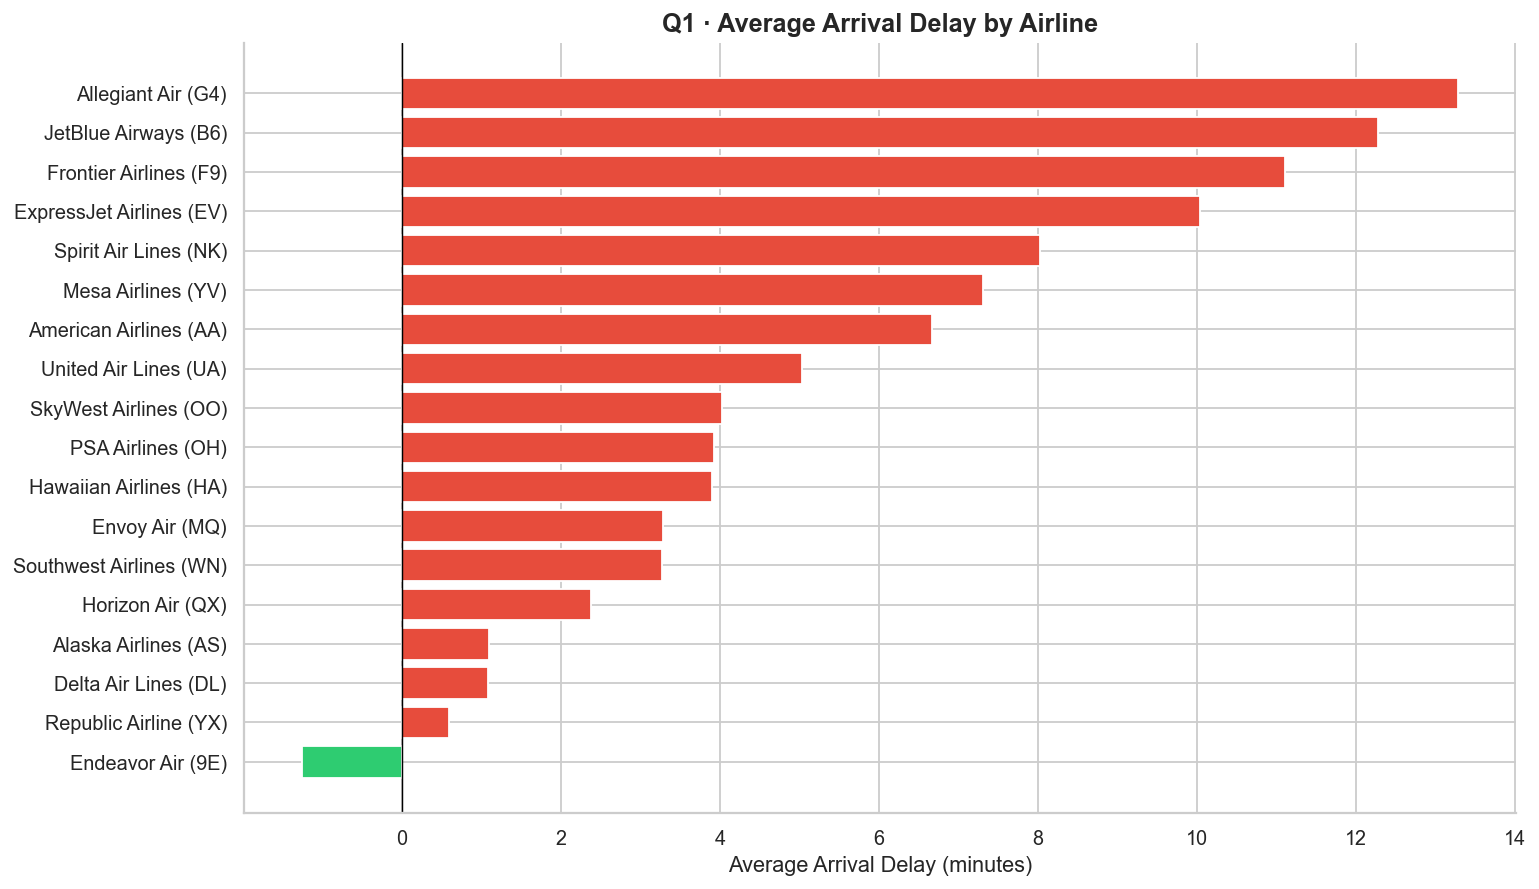

In [10]:
avg_delay = (
    completed.groupby("AIRLINE_CODE")["ARR_DELAY"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"ARR_DELAY": "AVG_ARR_DELAY"})
)
avg_delay["AIRLINE_LABEL"] = (avg_delay["AIRLINE_CODE"].map(airline_names)
                              + " (" + avg_delay["AIRLINE_CODE"] + ")")

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in avg_delay["AVG_ARR_DELAY"]]
ax.barh(avg_delay["AIRLINE_LABEL"], avg_delay["AVG_ARR_DELAY"],
        color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Average Arrival Delay (minutes)")
ax.set_title("Q1 · Average Arrival Delay by Airline")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Findings:**
- **Allegiant (G4), JetBlue (B6), Frontier (F9)** are the worst performers — all ultra-low-cost carriers operating tight turnarounds with little slack to absorb disruptions
- **Endeavor Air (9E)** is the only airline with a negative average — arriving early on average, likely due to padded schedules on short regional routes
- Every other airline has a positive average delay, meaning the typical flight arrives late

---
### Q2 · Airline delay frequency

Q1 measures *how bad* delays are when they happen. Q2 measures *how often* they happen. These can tell very different stories — an airline can have rare but long delays, or frequent but short ones.

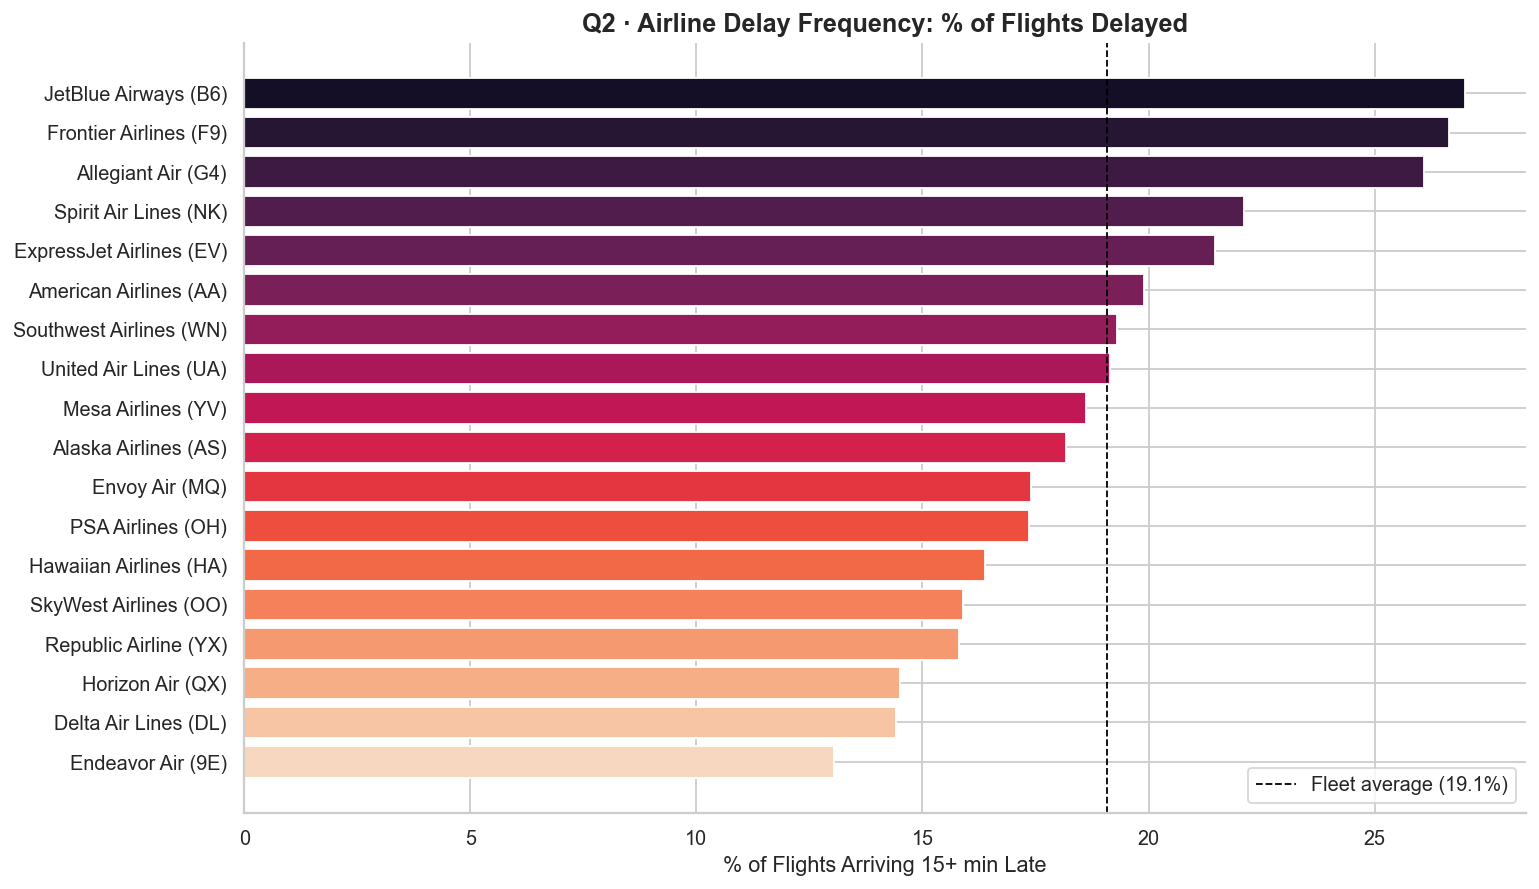

                 Airline  Flights  Delayed  Rate (%)
    JetBlue Airways (B6)   109447    29553     27.00
  Frontier Airlines (F9)    62712    16712     26.65
      Allegiant Air (G4)    50179    13091     26.09
   Spirit Air Lines (NK)    93200    20615     22.12
ExpressJet Airlines (EV)    17951     3856     21.48
  American Airlines (AA)   371218    73864     19.90
 Southwest Airlines (WN)   555869   107275     19.30
   United Air Lines (UA)   248270    47559     19.16
      Mesa Airlines (YV)    62477    11637     18.63
    Alaska Airlines (AS)    98294    17870     18.18
          Envoy Air (MQ)   117312    20406     17.39
       PSA Airlines (OH)   103483    17956     17.35
  Hawaiian Airlines (HA)    31698     5192     16.38
   SkyWest Airlines (OO)   334986    53222     15.89
   Republic Airline (YX)   138148    21830     15.80
        Horizon Air (QX)    20237     2937     14.51
    Delta Air Lines (DL)   388475    55964     14.41
       Endeavor Air (9E)   109848    14324    

In [11]:
delay_rate = (
    completed.groupby("AIRLINE_CODE")
    .agg(total_flights=("IS_DELAYED", "count"),
         delayed_flights=("IS_DELAYED", "sum"))
    .assign(delay_rate_pct=lambda x: x["delayed_flights"] / x["total_flights"] * 100)
    .sort_values("delay_rate_pct", ascending=False)
    .reset_index()
)
delay_rate["AIRLINE_LABEL"] = (delay_rate["AIRLINE_CODE"].map(airline_names)
                               + " (" + delay_rate["AIRLINE_CODE"] + ")")

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette("rocket", len(delay_rate))
ax.barh(delay_rate["AIRLINE_LABEL"], delay_rate["delay_rate_pct"],
        color=palette, edgecolor="white")
ax.axvline(delay_rate["delay_rate_pct"].mean(), color="black", linestyle="--",
           linewidth=1, label=f"Fleet average ({delay_rate['delay_rate_pct'].mean():.1f}%)")
ax.set_xlabel("% of Flights Arriving 15+ min Late")
ax.set_title("Q2 · Airline Delay Frequency: % of Flights Delayed")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

print(delay_rate[["AIRLINE_LABEL","total_flights","delayed_flights","delay_rate_pct"]]
      .rename(columns={"AIRLINE_LABEL": "Airline", "total_flights": "Flights",
                       "delayed_flights": "Delayed", "delay_rate_pct": "Rate (%)"})
      .to_string(index=False))

**Findings — comparing Q2 (frequency) to Q1 (magnitude):**
- **Allegiant drops from 1st to 3rd** — when it's late it's very late, but JetBlue and Frontier are delayed *more often*
- **Southwest (WN) jumps into view** — low average magnitude (Q1) but 19.3% of flights delayed; with 555k flights that's 107k delayed flights — the most of any airline in absolute terms
- **Delta (DL) and Endeavor (9E) are consistently best** on both metrics — rare delays and short ones when they happen
- **Alaska (AS)** has moderate frequency but low magnitude — delays are common but short

#### Q1 + Q2 combined: frequency vs magnitude scatter

Plotting both metrics together puts every airline into one of four quadrants.

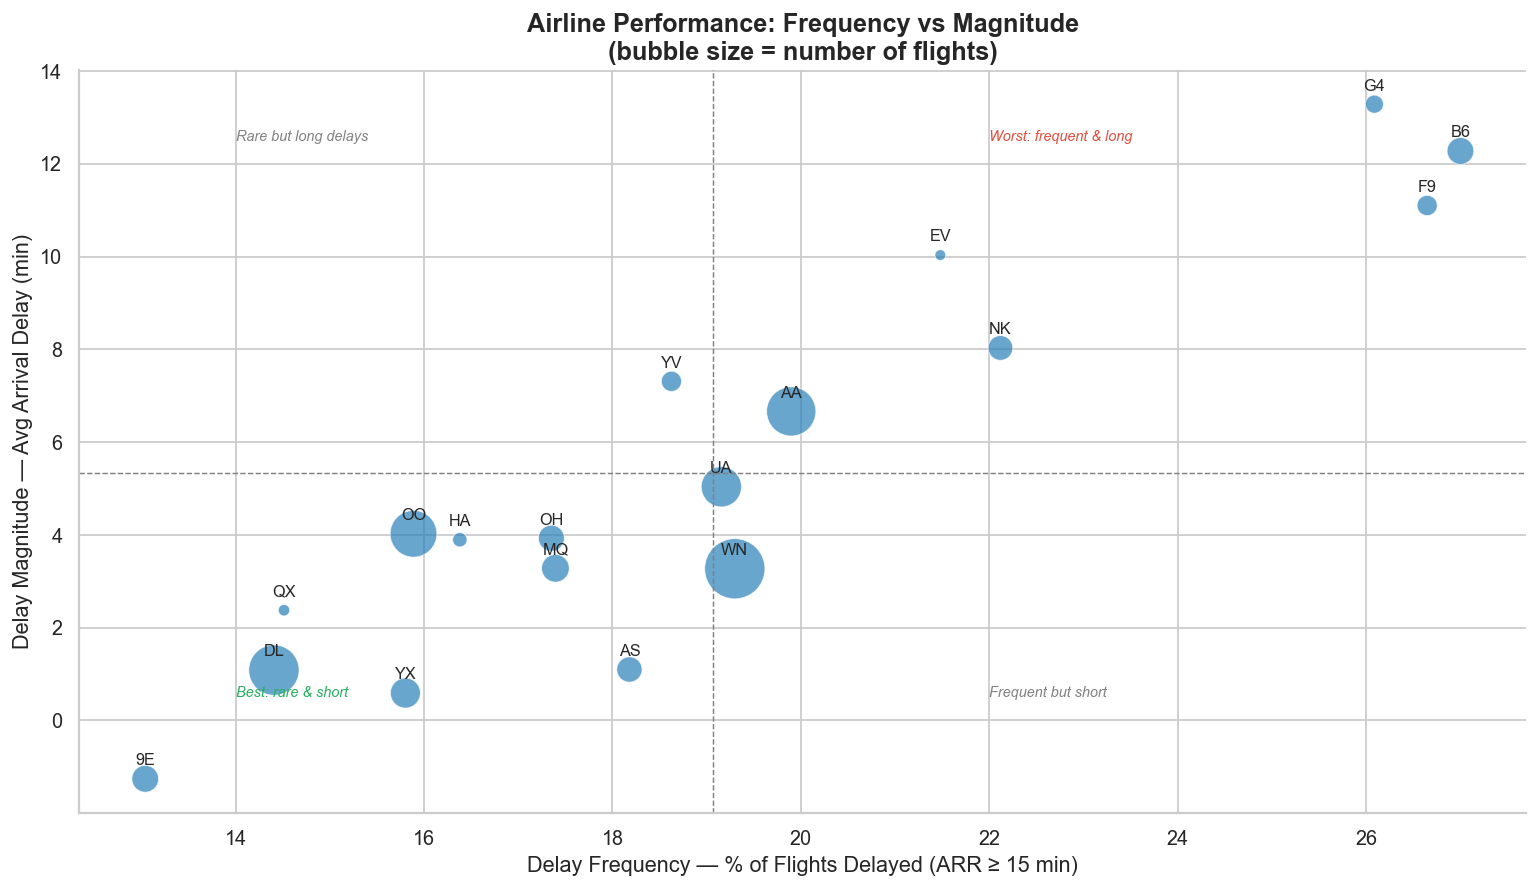

In [12]:
combined = avg_delay.merge(
    delay_rate[["AIRLINE_CODE", "delay_rate_pct", "total_flights"]], on="AIRLINE_CODE"
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(combined["delay_rate_pct"], combined["AVG_ARR_DELAY"],
           s=combined["total_flights"] / 500,
           alpha=0.7, color="#2980b9", edgecolors="white", linewidth=0.5)

for _, row in combined.iterrows():
    ax.annotate(row["AIRLINE_CODE"],
                (row["delay_rate_pct"], row["AVG_ARR_DELAY"]),
                fontsize=9, ha="center", va="bottom",
                xytext=(0, 6), textcoords="offset points")

# Quadrant lines at fleet averages
ax.axvline(combined["delay_rate_pct"].mean(), color="grey", linestyle="--", linewidth=0.8)
ax.axhline(combined["AVG_ARR_DELAY"].mean(),  color="grey", linestyle="--", linewidth=0.8)

ax.text(14, 12.5, "Rare but long delays",   fontsize=8, color="grey",    style="italic")
ax.text(22, 12.5, "Worst: frequent & long", fontsize=8, color="#e74c3c", style="italic")
ax.text(14, 0.5,  "Best: rare & short",     fontsize=8, color="#27ae60", style="italic")
ax.text(22, 0.5,  "Frequent but short",     fontsize=8, color="grey",    style="italic")

ax.set_xlabel("Delay Frequency — % of Flights Delayed (ARR ≥ 15 min)")
ax.set_ylabel("Delay Magnitude — Avg Arrival Delay (min)")
ax.set_title("Airline Performance: Frequency vs Magnitude\n(bubble size = number of flights)")
plt.tight_layout()
plt.show()

---
### Q3 · Most common cause of delays

Using the `delayed` subset (ARR_DELAY ≥ 15 min). The BTS only requires airlines to file cause codes above this threshold, so this is the only subset where the cause columns are complete and meaningful.

Delay minutes by cause:
  Late Aircraft        13.60M min  (37.7%)
  Carrier              13.22M min  (36.7%)
  Nat. Air System      7.03M min  (19.5%)
  Weather              2.13M min  (5.9%)
  Security             0.08M min  (0.2%)


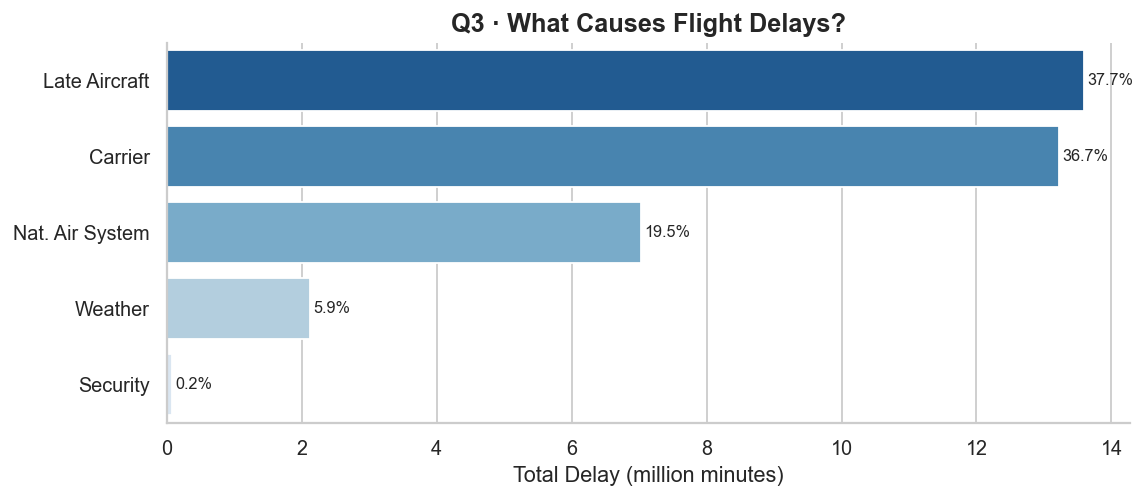

In [14]:
# Q3 · Most common cause of delays
# Using `delayed` subset — cause columns are only populated above the BTS 15-minute reporting threshold

cause_totals = (
    delayed[CAUSE_COLS].sum()
    .rename({"DELAY_DUE_CARRIER": "Carrier", "DELAY_DUE_WEATHER": "Weather",
             "DELAY_DUE_NAS": "Nat. Air System", "DELAY_DUE_SECURITY": "Security",
             "DELAY_DUE_LATE_AIRCRAFT": "Late Aircraft"})
    .sort_values(ascending=False)
)
cause_pct = (cause_totals / cause_totals.sum() * 100).round(1)

print("Delay minutes by cause:")
for cause, mins in cause_totals.items():
    print(f"  {cause:<20} {mins/1e6:.2f}M min  ({cause_pct[cause]:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=cause_totals.values / 1e6, y=cause_totals.index, palette="Blues_r", ax=ax)
for i, (val, pct) in enumerate(zip(cause_totals.values, cause_pct.values)):
    ax.text(val / 1e6 + 0.05, i, f"{pct:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Total Delay (million minutes)")
ax.set_title("Q3 · What Causes Flight Delays?")
plt.tight_layout()
plt.show()

**Findings:**
- **Late Aircraft + Carrier = 74.4%** — nearly 3 in 4 delay minutes are operationally driven and within the airline's control to varying degrees
- **NAS at 19.5%** — reflects the 62,056 flights that depart on time but arrive late due to ATC congestion in the air
- **Weather is only 5.9%** — contrary to popular belief
- **Security at 0.2%** — essentially negligible

#### Q3 extension · Delay cause breakdown by airline

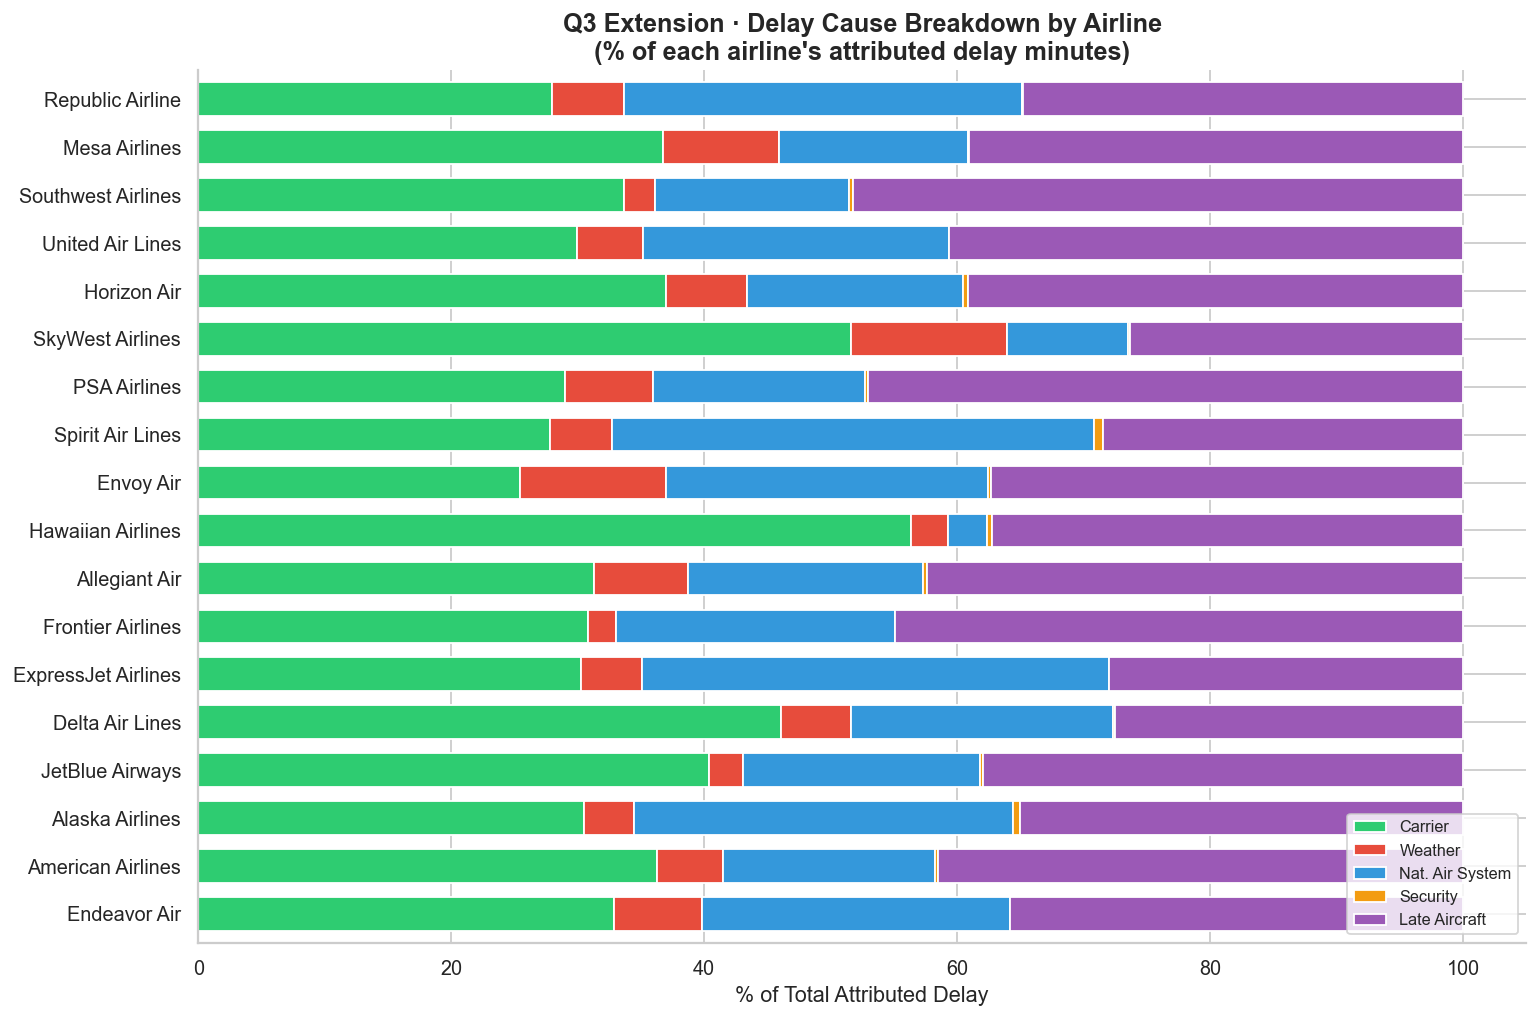

In [15]:
cause_by_airline = (
    delayed.groupby("AIRLINE_CODE")[CAUSE_COLS].sum()
    .rename(columns={"DELAY_DUE_CARRIER": "Carrier", "DELAY_DUE_WEATHER": "Weather",
                     "DELAY_DUE_NAS": "Nat. Air System", "DELAY_DUE_SECURITY": "Security",
                     "DELAY_DUE_LATE_AIRCRAFT": "Late Aircraft"})
)
# Normalise to % of each airline's total attributed delay for fair comparison
cause_by_airline_pct = cause_by_airline.div(cause_by_airline.sum(axis=1), axis=0) * 100
cause_by_airline_pct.index = cause_by_airline_pct.index.map(airline_names)

fig, ax = plt.subplots(figsize=(12, 8))
cause_by_airline_pct.plot(
    kind="barh", stacked=True, ax=ax,
    color=["#2ecc71", "#e74c3c", "#3498db", "#f39c12", "#9b59b6"],
    edgecolor="white", width=0.7
)
ax.set_xlabel("% of Total Attributed Delay")
ax.set_ylabel("")
ax.set_title("Q3 Extension · Delay Cause Breakdown by Airline\n(% of each airline's attributed delay minutes)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Findings:**
- **Hawaiian Airlines (HA)** is almost entirely NAS-driven — island network with limited routing, so delays happen in the air (ATC/airspace) rather than cascading from previous flights
- **Southwest (WN)** has almost no Weather bar — point-to-point model absorbs weather locally without network cascades
- **Regional carriers (Republic YX, Mesa YV, PSA OH)** have large Late Aircraft bars — tight turnaround schedules with no slack mean one late inbound aircraft cascades immediately
- **SkyWest (OO)** has a notably large Weather bar — serves smaller airports in mountainous western states disproportionately affected by weather

---
### Q4 · Average delay by day of week

Using `FULL_NORMAL_YEARS` (2019, 2021, 2022) to exclude COVID distortion and the partial 2023 year.

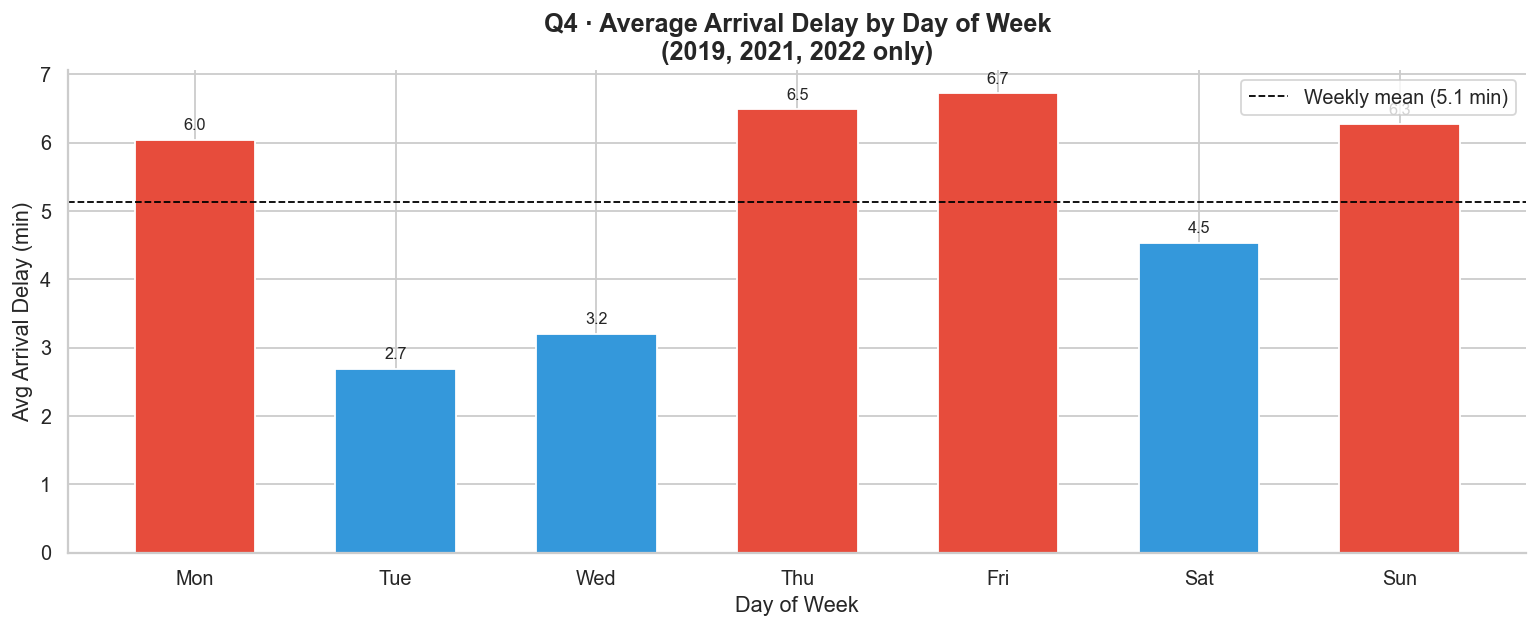

DOW_NAME  AVG_ARR_DELAY
     Mon           6.04
     Tue           2.69
     Wed           3.20
     Thu           6.49
     Fri           6.72
     Sat           4.54
     Sun           6.27


In [22]:
dow_delay = (
    completed[completed["YEAR"].isin(FULL_NORMAL_YEARS)]
    .groupby("DOW_NAME")["ARR_DELAY"]
    .mean()
    .reindex(DOW_ORDER)
    .reset_index()
    .rename(columns={"ARR_DELAY": "AVG_ARR_DELAY"})
)
overall_mean = dow_delay["AVG_ARR_DELAY"].mean()

fig, ax = plt.subplots()
colors = ["#e74c3c" if v > overall_mean else "#3498db" for v in dow_delay["AVG_ARR_DELAY"]]
bars = ax.bar(dow_delay["DOW_NAME"], dow_delay["AVG_ARR_DELAY"],
              color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, dow_delay["AVG_ARR_DELAY"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9)
ax.axhline(overall_mean, color="black", linestyle="--",
           linewidth=1, label=f"Weekly mean ({overall_mean:.1f} min)")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Avg Arrival Delay (min)")
ax.set_title("Q4 · Average Arrival Delay by Day of Week\n(2019, 2021, 2022 only)")
ax.legend()
plt.tight_layout()
plt.show()

print(dow_delay.to_string(index=False))

**Findings:**
- **Friday is the worst day (6.7 min)** — peak business + leisure travel combined; network congestion cascades from the week
- **Thursday is close behind (6.5 min)** — business travellers departing early to arrive Friday
- **Monday is surprisingly bad (6.0 min)** — return wave from weekend travel creates Late Aircraft cascades into Monday morning
- **Tuesday and Wednesday are the best days to fly (2.7 and 3.2 min)** — mid-week lull in both business and leisure demand
- **Saturday is better than expected (4.5 min)** — leisure-heavy but fewer connecting passengers means fewer cascading delays

> **Practical tip:** fly Tuesday or Wednesday. Avoid Friday and Thursday.

---
### Q5 · Average delay by month

Using `FULL_NORMAL_YEARS` (2019, 2021, 2022) to exclude COVID distortion and the partial 2023 year.

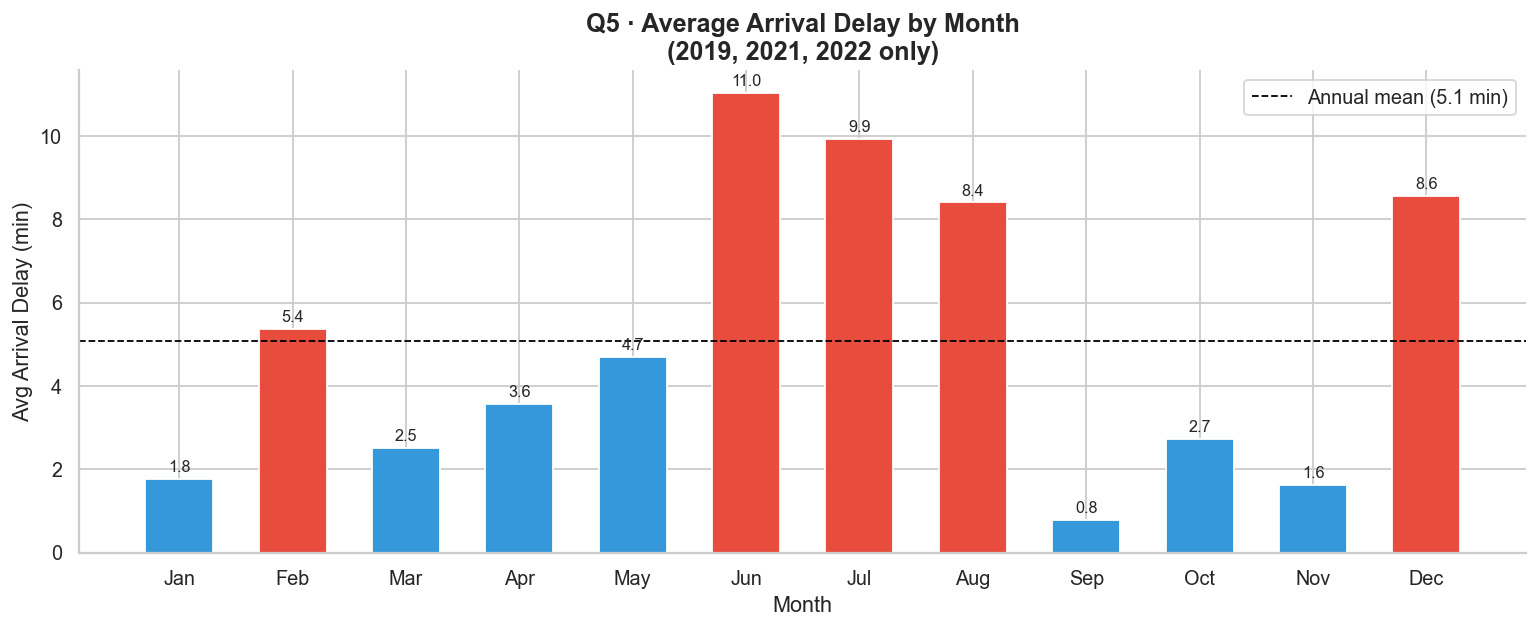

MONTH_NAME  AVG_ARR_DELAY
       Jan           1.76
       Feb           5.36
       Mar           2.51
       Apr           3.57
       May           4.69
       Jun          11.02
       Jul           9.92
       Aug           8.41
       Sep           0.78
       Oct           2.72
       Nov           1.63
       Dec           8.57


In [23]:
month_delay = (
    completed[completed["YEAR"].isin(FULL_NORMAL_YEARS)]
    .groupby("MONTH_NAME")["ARR_DELAY"]
    .mean()
    .reindex(MONTH_ORDER)
    .reset_index()
    .rename(columns={"ARR_DELAY": "AVG_ARR_DELAY"})
)
overall_mean = month_delay["AVG_ARR_DELAY"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#e74c3c" if v > overall_mean else "#3498db" for v in month_delay["AVG_ARR_DELAY"]]
bars = ax.bar(month_delay["MONTH_NAME"], month_delay["AVG_ARR_DELAY"],
              color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, month_delay["AVG_ARR_DELAY"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9)
ax.axhline(overall_mean, color="black", linestyle="--",
           linewidth=1, label=f"Annual mean ({overall_mean:.1f} min)")
ax.set_xlabel("Month")
ax.set_ylabel("Avg Arrival Delay (min)")
ax.set_title("Q5 · Average Arrival Delay by Month\n(2019, 2021, 2022 only)")
ax.legend()
plt.tight_layout()
plt.show()

print(month_delay.to_string(index=False))

**Findings:**
- **June is the worst month (11.0 min)** — peak summer demand meets afternoon thunderstorm season across the South and Midwest; network at maximum load
- **July and August follow (9.9 and 8.4 min)** — full summer surge; three consecutive months well above the annual mean
- **December spike (8.6 min)** — holiday travel plus winter weather; worse than January (1.8 min), showing the Christmas rush matters more than winter weather alone
- **February (5.4 min)** — the only non-summer month above the mean; nor'easters and ice storms peak here
- **September is the best month (0.8 min)** — summer travel ends, schools are back, no holidays, thunderstorm season winds down

> **Practical tip:** fly in September. Avoid June. Combined with Q4: the worst possible combination is a **Friday in June**; the best is a **Tuesday in September**.

---
### Q6 · Does a departure delay predict an arrival delay?

We test the relationship between `DEP_DELAY` and `ARR_DELAY` on completed flights. A random sample of 50,000 is used for the scatter plot — plotting 2.9M points would be unreadable and computationally heavy.

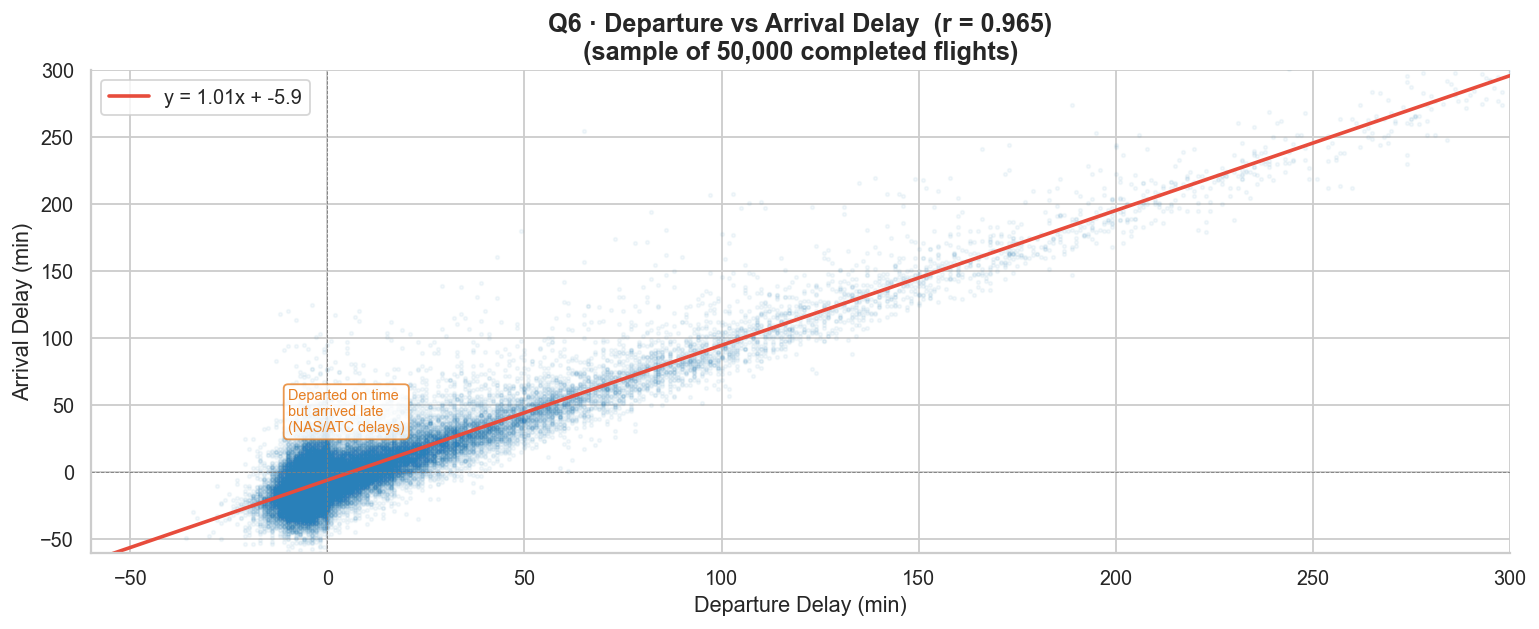

Correlation (DEP_DELAY vs ARR_DELAY) : 0.9648
Best-fit line                         : ARR_DELAY = 1.01 × DEP_DELAY + -5.9

Avg time recovered in air             : 5.8 min
Flights where airline recovered time  : 2,134,463 (73.3%)
Flights where delay worsened in air   : 779,341 (26.7%)


In [24]:
sample = (completed[["DEP_DELAY", "ARR_DELAY"]].dropna()
          .sample(50_000, random_state=SEED))

corr = completed[["DEP_DELAY", "ARR_DELAY"]].corr().loc["DEP_DELAY", "ARR_DELAY"]
m, b = np.polyfit(sample["DEP_DELAY"], sample["ARR_DELAY"], 1)
x_line = np.linspace(-60, 300, 200)

fig, ax = plt.subplots()
ax.scatter(sample["DEP_DELAY"], sample["ARR_DELAY"],
           alpha=0.05, s=4, color="#2980b9")
ax.plot(x_line, m * x_line + b, color="#e74c3c",
        linewidth=2, label=f"y = {m:.2f}x + {b:.1f}")
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
ax.annotate("Departed on time\nbut arrived late\n(NAS/ATC delays)",
            xy=(-10, 30), fontsize=8, color="#e67e22",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#e67e22", alpha=0.8))
ax.set_xlim(-60, 300)
ax.set_ylim(-60, 300)
ax.set_xlabel("Departure Delay (min)")
ax.set_ylabel("Arrival Delay (min)")
ax.set_title(f"Q6 · Departure vs Arrival Delay  (r = {corr:.3f})\n(sample of 50,000 completed flights)")
ax.legend()
plt.tight_layout()
plt.show()

# Time recovery analysis
completed_copy = completed.copy()
completed_copy["TIME_RECOVERED"] = completed_copy["DEP_DELAY"] - completed_copy["ARR_DELAY"]
mean_rec     = completed_copy["TIME_RECOVERED"].mean()
recovered    = (completed_copy["TIME_RECOVERED"] > 0).sum()
recovered_pct = recovered / len(completed_copy) * 100

print(f"Correlation (DEP_DELAY vs ARR_DELAY) : {corr:.4f}")
print(f"Best-fit line                         : ARR_DELAY = {m:.2f} × DEP_DELAY + {b:.1f}")
print(f"\nAvg time recovered in air             : {mean_rec:.1f} min")
print(f"Flights where airline recovered time  : {recovered:,} ({recovered_pct:.1f}%)")
print(f"Flights where delay worsened in air   : {len(completed_copy)-recovered:,} ({100-recovered_pct:.1f}%)")

**Findings:**
- **r = 0.965 — near-perfect correlation** — departure delay is an extremely strong predictor of arrival delay
- **Slope ≈ 1.01 — delays transfer almost 1:1** — every extra minute at the gate means approximately one extra minute late on arrival
- **Intercept = -5.9 — airlines recover ~6 minutes on average** — pilots push speed slightly and ATC often helps when a flight is known to be running late
- **73.3% of flights recover some time in the air** — nearly 3 in 4 completed flights arrive closer to schedule than they departed
- **The NAS cluster is visible** — the spread of dots in the upper-left quadrant (departed on time, arrived late) represents the 62k NAS-delayed flights identified in cleaning

> **Practical tip:** if your flight is delayed at the gate, expect to arrive roughly as late as you departed, minus about 6 minutes. A 30-minute departure delay → ~24-minute arrival delay.

---
## 4 · Summary

### Results of the analysis

| Question | Key finding |
|---|---|
| Q1 · Avg delay per airline | Allegiant (13.4 min), JetBlue (12.3 min), Frontier (11.1 min) are worst; Endeavor Air is only airline arriving early on average |
| Q2 · Delay frequency | JetBlue (27%), Frontier (26.7%), Allegiant (26.1%) have most frequent delays; Delta (14.4%) and Endeavor (13%) best |
| Q3 · Delay causes | Late Aircraft (37.7%) + Carrier (36.7%) = 74% of delay; weather undercounted due to cascade attribution |
| Q4 · Delay by day | Worst: Friday (6.7 min); Best: Tuesday (2.7 min) |
| Q5 · Delay by month | Worst: June (11.0 min); Best: September (0.8 min) |
| Q6 · Dep → Arr delay | r = 0.965; slope ≈ 1; airlines recover ~6 min on average; 73% of flights improve in the air |

